# Week 7: Evaluations
### Author: Rajit Rajpal
The goal of this tutorial will be to learn about diffusion models as a latent variable model. `# TODO` are for you to implement. Solutions will contain the completed code. 

We will:
1. Formulate the forward process $q(x_{1:T}|x_0)$.
2. Parameterize the reverse process $p_\theta(x_{t-1}|x_t) = \mathcal{N}(\mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$.
3. Optimize the Variational Lower Bound (VLB) directly by calculating the KL divergence between the true posterior $q(x_{t-1}|x_t, x_0)$ and our model $p_\theta$.
4. Learn the log-variance dynamically.
5. Swap standard Gaussian noise for a Blurring forward process using the *exact same objective*.

### Imports

In [ ]:
# %pip install numpy matplotlib torch torchvision scipy pillow scikit-learn

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import PIL
from scipy.ndimage import gaussian_filter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import ipywidgets as widgets
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set seed
torch.manual_seed(42)
np.random.seed(42)

### Data

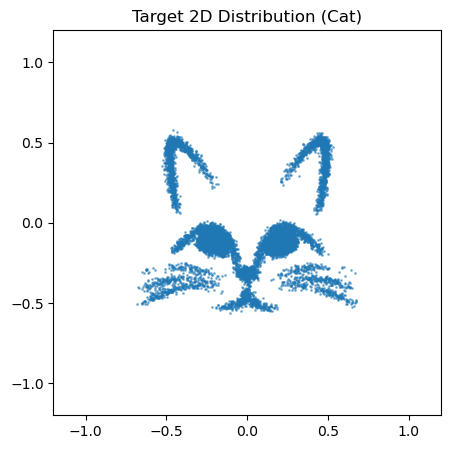

In [3]:
# --- 2D Cat Dataset ---
def get_cat_samples(n_samples=10000, sigma=2.0):
    try:
        cat = PIL.Image.open("cat.png").convert('L')
        arr = 1.0 - (np.array(cat) / 255.0) 
        smoothed_arr = gaussian_filter(arr, sigma=sigma)
        prob_map = smoothed_arr / smoothed_arr.sum()
    except FileNotFoundError:
        print("Cat image not found, using a fallback density.")
        return torch.randn(n_samples, 2) * 0.5

    flat_probs = prob_map.flatten()
    indices = np.random.choice(len(flat_probs), size=n_samples, p=flat_probs)
    rows, cols = np.unravel_index(indices, prob_map.shape)
    
    points = np.zeros((n_samples, 2))
    points[:, 0] = (cols / prob_map.shape[1]) * 2 - 1
    points[:, 1] = 1 - (rows / prob_map.shape[0]) * 2
    points += np.random.normal(0, 0.01, points.shape)
    
    return torch.from_numpy(points).float()

cat_data = get_cat_samples(10000, sigma=3.0).to(device)

# --- MNIST Dataset ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Map to [-1, 1]
])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_loader = DataLoader(mnist_dataset, batch_size=128, shuffle=True)

# Plot the 2D Cat
plt.figure(figsize=(5,5))
plt.scatter(cat_data[:, 0].cpu(), cat_data[:, 1].cpu(), s=1, alpha=0.5)
plt.title("Target 2D Distribution (Cat)")
plt.xlim(-1.2, 1.2); plt.ylim(-1.2, 1.2)
plt.show()

### Noise Schedules

The forward process adds noise according to a variance schedule $\beta_t$. 
Let's define Linear, Cosine, and Sigmoid schedules and interactively observe how they destroy our 2D data!

In [4]:
def get_beta_schedule(schedule_type, num_timesteps):
    if schedule_type == 'linear':
        scale = 1000 / num_timesteps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        return torch.linspace(beta_start, beta_end, num_timesteps)
    elif schedule_type == 'cosine':
        steps = num_timesteps + 1
        s = 0.008
        t = torch.linspace(0, num_timesteps, steps)
        alphas_cumprod = torch.cos(((t / num_timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0, 0.999)

def plot_forward_process(schedule_type, timestep):
    T = 100
    betas = get_beta_schedule(schedule_type, T)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    if timestep == 0:
        x_t = cat_data.cpu()
    else:
        alpha_bar_t = alphas_cumprod[timestep-1]
        noise = torch.randn_like(cat_data)
        x_t = torch.sqrt(alpha_bar_t) * cat_data + torch.sqrt(1 - alpha_bar_t) * noise
        
    plt.figure(figsize=(5,5))
    plt.scatter(x_t[:, 0].cpu(), x_t[:, 1].cpu(), s=1, alpha=0.3)
    plt.xlim(-3, 3); plt.ylim(-3, 3)
    plt.title(f"Schedule: {schedule_type} | Timestep: {timestep}/{T}")
    plt.show()

widgets.interact(plot_forward_process, 
                 schedule_type=widgets.Dropdown(options=['linear', 'cosine'], value='linear'),
                 timestep=widgets.IntSlider(min=0, max=100, step=1, value=0));

interactive(children=(Dropdown(description='schedule_type', options=('linear', 'cosine'), value='linear'), Int…

Unlike typical DDPMs that predict the noise $\epsilon$ and assume fixed variance, our network will directly predict:
1. The mean $\mu_\theta(x_t, t)$
2. The log-variance $\log \Sigma_\theta(x_t, t)$

We optimize the Variational Lower Bound. At step $t$, the loss is the KL divergence between two Gaussians:
$$L_t = D_{KL}(q(x_{t-1}|x_t, x_0) || p_\theta(x_{t-1}|x_t))$$

For two Gaussians $q(\mu_1, \sigma_1^2)$ and $p(\mu_2, \sigma_2^2)$, the KL divergence is:
$$\frac{1}{2} \left[ \log\frac{\sigma_2^2}{\sigma_1^2} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{\sigma_2^2} - 1 \right]$$

In [5]:
class VBEDiffusionModel(nn.Module):
    def __init__(self, data_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(data_dim + 1, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, data_dim * 2) # Outputs both mean and log_var
        )
        
    def forward(self, x, t):
        t_input = t.unsqueeze(-1).float() / 100.0 # Normalize t
        x_input = torch.cat([x, t_input], dim=-1)
        out = self.net(x_input)
        mu, log_var = torch.chunk(out, 2, dim=-1)
        return mu, log_var

def compute_kl_loss(model, x_0, t, betas):
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    
    alpha_t = alphas[t].view(-1, 1)
    alpha_bar_t = alphas_cumprod[t].view(-1, 1)
    alpha_bar_prev = alphas_cumprod_prev[t].view(-1, 1)
    beta_t = betas[t].view(-1, 1)
    
    # 1. Forward process: Sample x_t
    noise = torch.randn_like(x_0)
    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
    
    # 2. True posterior q(x_{t-1} | x_t, x_0)
    true_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * x_0 + \
              (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
    true_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
    true_log_var = torch.log(torch.clamp(true_var, min=1e-20))
    
    # 3. Model prediction p_theta(x_{t-1} | x_t)
    pred_mu, pred_log_var = model(x_t, t)
    
    # 4. KL Divergence
    # D_KL(q || p) = 0.5 * ( (true_var + (true_mu - pred_mu)^2) / pred_var + pred_log_var - true_log_var - 1 )
    pred_var = torch.exp(pred_log_var)
    kl = 0.5 * ( (true_var + (true_mu - pred_mu)**2) / pred_var + pred_log_var - true_log_var - 1 )
    
    return kl.mean()

# Initialize 2D Model
T = 100
betas = get_beta_schedule('linear', T).to(device)
model_2d = VBEDiffusionModel(data_dim=2).to(device)
optimizer = torch.optim.Adam(model_2d.parameters(), lr=1e-3)

What if instead of just scaling by $\sqrt{1-\beta}$ and adding noise, our forward process mathematically applies a local blur (mixing points) AND adds noise? 

Because we formulated this purely as a latent variable model, the objective doesn't change! We only need to redefine $q(x_{t}|x_{t-1})$ and derive its posterior $q(x_{t-1}|x_t, x_0)$. 

*Note for 2D:* Blurring in continuous 2D space essentially pulls points towards the origin (global mean) or local neighborhoods. We will simulate "Blurring Diffusion" by strongly increasing the decay factor and reducing the noise, mapping it to a deterministic decay path plus tiny stochasticity.

In [6]:
def compute_blur_kl_loss(model, x_0, t, betas):
    # Simulated Blur: Stronger drift towards 0, very little noise.
    # q(x_t | x_0) = N(x_t; a_t x_0, b_t I)
    
    # Custom blur schedule
    a_t = torch.cos((t.float() / T) * (torch.pi / 2)).view(-1, 1) # Deterministic decay
    b_t = (betas[t] * 0.1).view(-1, 1) # Tiny noise for mathematical stability
    
    a_prev = torch.cos(((t.float()-1).clamp(min=0) / T) * (torch.pi / 2)).view(-1, 1)
    b_prev = (betas[(t-1).clamp(min=0)] * 0.1).view(-1, 1)

    noise = torch.randn_like(x_0)
    x_t = a_t * x_0 + torch.sqrt(b_t) * noise
    
    # Deriving true posterior q(x_{t-1} | x_t, x_0) for the blur process
    # By Bayes rule, this is proportional to N(x_t | x_{t-1}) * N(x_{t-1} | x_0)
    # (Simplified analytical posterior for custom a_t, b_t)
    var_t_given_prev = b_t - (a_t/a_prev)**2 * b_prev # simplified variance transition
    var_t_given_prev = torch.clamp(var_t_given_prev, min=1e-5)
    
    true_var = 1.0 / (1.0/var_t_given_prev + 1.0/b_prev)
    true_mu = true_var * ( (x_t - (a_t/a_prev)*0) / var_t_given_prev + (a_prev * x_0) / b_prev )
    true_log_var = torch.log(true_var)
    
    pred_mu, pred_log_var = model(x_t, t)
    
    pred_var = torch.exp(pred_log_var)
    kl = 0.5 * ( (true_var + (true_mu - pred_mu)**2) / pred_var + pred_log_var - true_log_var - 1 )
    return kl.mean()

# You can swap `compute_kl_loss` for `compute_blur_kl_loss` in the training loop!

Let's train the 2D model and plot the denoising trajectory. You can extend the architecture to a UNet for the MNIST dataloader provided above!

Epoch 0 | Loss: 1.1833
Epoch 500 | Loss: 0.0416
Epoch 1000 | Loss: 0.0221
Epoch 1500 | Loss: 0.0234


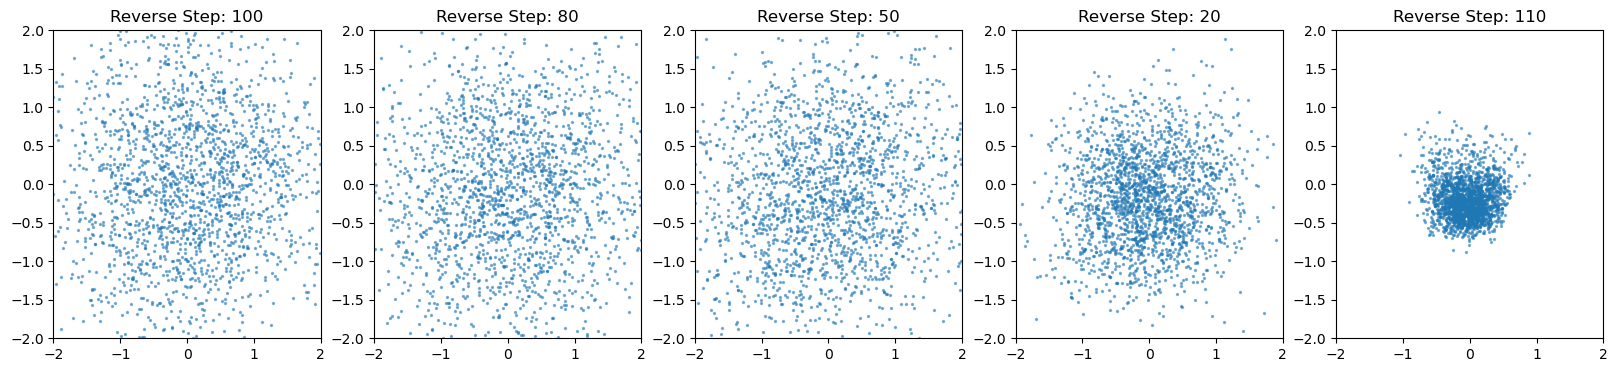

In [7]:
# Simple Training Loop
epochs = 2000
batch_size = 512

model_2d.train()
for epoch in range(epochs):
    idx = torch.randint(0, len(cat_data), (batch_size,))
    x_0 = cat_data[idx]
    
    # Sample random timesteps
    t = torch.randint(1, T, (batch_size,), device=device)
    
    loss = compute_kl_loss(model_2d, x_0, t, betas)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# Denoising and Trajectory plotting
@torch.no_grad()
def plot_reverse_process():
    model_2d.eval()
    x_t = torch.randn(2000, 2, device=device)
    
    history = [x_t.cpu().numpy()]
    
    for t in reversed(range(1, T)):
        t_tensor = torch.full((len(x_t),), t, device=device, dtype=torch.long)
        pred_mu, pred_log_var = model_2d(x_t, t_tensor)
        
        noise = torch.randn_like(x_t) if t > 1 else torch.zeros_like(x_t)
        x_t = pred_mu + torch.exp(0.5 * pred_log_var) * noise
        
        if t % 10 == 0 or t == 1:
            history.append(x_t.cpu().numpy())
            
    # Plotting
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    plot_steps = [0, len(history)//4, len(history)//2, 3*len(history)//4, -1]
    for i, step in enumerate(plot_steps):
        axes[i].scatter(history[step][:, 0], history[step][:, 1], s=2, alpha=0.5)
        axes[i].set_title(f"Reverse Step: {T - (step*10)}")
        axes[i].set_xlim(-2, 2); axes[i].set_ylim(-2, 2)
    plt.show()

plot_reverse_process()

### 2D Spatial Diffusion (MNIST)
Now we move from 2D coordinates to 2D image grids (1x28x28 pixels). We will use a lightweight U-Net architecture. 

To parameterize $p_\theta(x_{t-1}|x_t) = \mathcal{N}(\mu_\theta, \Sigma_\theta)$, our U-Net takes in a noisy 1-channel image and the current timestep $t$. The final convolutional layer outputs **2 channels**. We slice this output in half: channel 0 is our predicted mean, and channel 1 is our predicted log-variance.

In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Maps the scalar timestep t into a high-dimensional vector."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class SimpleConvBlock(nn.Module):
    """A basic convolutional block with time embedding injection."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn = nn.GroupNorm(4, out_ch) # GroupNorm is more stable than BatchNorm for small batches
        self.relu = nn.GELU()

    def forward(self, x, t_emb):
        # First convolution
        h = self.relu(self.bn(self.conv1(x)))
        
        # Inject time embedding
        time_emb = self.relu(self.time_mlp(t_emb))
        # Reshape time_emb to match spatial dimensions (B, C, 1, 1)
        time_emb = time_emb.unsqueeze(-1).unsqueeze(-1)
        h = h + time_emb
        
        # Second convolution
        h = self.relu(self.bn(self.conv2(h)))
        return h

class CPU_UNet_MNIST(nn.Module):
    def __init__(self, in_channels=1, hidden_dims=16):
        super().__init__()
        time_dim = hidden_dims * 4
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dims),
            nn.Linear(hidden_dims, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim)
        )
        
        # Downsampling path
        self.down1 = SimpleConvBlock(in_channels, hidden_dims, time_dim)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = SimpleConvBlock(hidden_dims, hidden_dims * 2, time_dim)
        self.pool2 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = SimpleConvBlock(hidden_dims * 2, hidden_dims * 4, time_dim)
        
        # Upsampling path
        self.up1 = nn.ConvTranspose2d(hidden_dims * 4, hidden_dims * 2, kernel_size=2, stride=2)
        self.up_conv1 = SimpleConvBlock(hidden_dims * 4, hidden_dims * 2, time_dim) # *4 because of skip connection
        
        self.up2 = nn.ConvTranspose2d(hidden_dims * 2, hidden_dims, kernel_size=2, stride=2)
        self.up_conv2 = SimpleConvBlock(hidden_dims * 2, hidden_dims, time_dim)
        
        # Final output layer: Outputs 2 channels! (Mean and Log-Variance)
        self.final_conv = nn.Conv2d(hidden_dims, 2, kernel_size=1)

    def forward(self, x, t):
        # 1. Embed time
        t_emb = self.time_mlp(t)
        
        # 2. Downsample
        d1 = self.down1(x, t_emb)      # shape: (B, 16, 28, 28)
        p1 = self.pool1(d1)            # shape: (B, 16, 14, 14)
        
        d2 = self.down2(p1, t_emb)     # shape: (B, 32, 14, 14)
        p2 = self.pool2(d2)            # shape: (B, 32, 7, 7)
        
        # 3. Bottleneck
        b = self.bottleneck(p2, t_emb) # shape: (B, 64, 7, 7)
        
        # 4. Upsample with skip connections
        u1 = self.up1(b)               # shape: (B, 32, 14, 14)
        u1 = torch.cat([u1, d2], dim=1)# shape: (B, 64, 14, 14)
        u1 = self.up_conv1(u1, t_emb)  # shape: (B, 32, 14, 14)
        
        u2 = self.up2(u1)              # shape: (B, 16, 28, 28)
        u2 = torch.cat([u2, d1], dim=1)# shape: (B, 32, 28, 28)
        u2 = self.up_conv2(u2, t_emb)  # shape: (B, 16, 28, 28)
        
        # 5. Predict mean and log-variance
        out = self.final_conv(u2)      # shape: (B, 2, 28, 28)
        
        # Split the output into two 1-channel images
        mu, log_var = torch.chunk(out, 2, dim=1)
        return mu, log_var

# Initialize the model on CPU
unet_model = CPU_UNet_MNIST().to(device)
print(f"Total trainable parameters: {sum(p.numel() for p in unet_model.parameters() if p.requires_grad):,}")

Total trainable parameters: 132,738


Because our `compute_kl_loss` function from Section 4 was built purely on PyTorch tensor math, it already handles arbitrary dimensional arrays gracefully! We just need to ensure the dimensions of our `alpha` and `beta` schedules match the 4D image shape `(Batch, Channels, Height, Width)` when we compute the loss.

In [9]:
def compute_image_kl_loss(model, x_0, t, betas):
    """Adapted KL Loss to handle (B, C, H, W) shapes."""
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    
    # Reshape schedules to broadcast over (B, C, H, W)
    alpha_t = alphas[t].view(-1, 1, 1, 1)
    alpha_bar_t = alphas_cumprod[t].view(-1, 1, 1, 1)
    alpha_bar_prev = alphas_cumprod_prev[t].view(-1, 1, 1, 1)
    beta_t = betas[t].view(-1, 1, 1, 1)
    
    # 1. Forward process: Sample x_t
    noise = torch.randn_like(x_0)
    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
    
    # 2. True posterior q(x_{t-1} | x_t, x_0)
    true_mu = (torch.sqrt(alpha_bar_prev) * beta_t / (1 - alpha_bar_t)) * x_0 + \
              (torch.sqrt(alpha_t) * (1 - alpha_bar_prev) / (1 - alpha_bar_t)) * x_t
    
    true_var = beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t)
    true_log_var = torch.log(torch.clamp(true_var, min=1e-20))
    
    # 3. Model prediction p_theta(x_{t-1} | x_t)
    pred_mu, pred_log_var = model(x_t, t)
    
    # 4. KL Divergence (averaged across batch and spatial dimensions)
    pred_var = torch.exp(pred_log_var)
    kl = 0.5 * ( (true_var + (true_mu - pred_mu)**2) / pred_var + pred_log_var - true_log_var - 1 )
    
    return kl.mean()

In [10]:
# Setup Training
epochs_mnist = 5 # Keep it low for CPU, increase to 50+ if on GPU
T = 100          # Total diffusion steps
betas = get_beta_schedule('linear', T).to(device)
optimizer_unet = torch.optim.Adam(unet_model.parameters(), lr=1e-3)

unet_model.train()
print("Starting U-Net Training on MNIST...")

for epoch in range(epochs_mnist):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(mnist_loader):
        images = images.to(device)
        batch_size = images.shape[0]
        
        # Sample random timesteps t in [1, T-1] for the batch
        t = torch.randint(1, T, (batch_size,), device=device)
        
        # Compute exact VLB Loss (KL Divergence)
        loss = compute_image_kl_loss(unet_model, images, t, betas)
        
        # Optimize
        optimizer_unet.zero_grad()
        loss.backward()
        optimizer_unet.step()
        
        total_loss += loss.item()
        
        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs_mnist} | Batch {batch_idx}/{len(mnist_loader)} | Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(mnist_loader)
    print(f"=== Epoch {epoch+1} Completed | Average Loss: {avg_loss:.4f} ===")

Starting U-Net Training on MNIST...
Epoch 1/5 | Batch 0/469 | Loss: 1.6558


KeyboardInterrupt: 

Let's see what our model learned! To generate a new image, we start with pure Gaussian noise $x_T \sim \mathcal{N}(0, I)$ and iteratively sample from our model $p_\theta(x_{t-1}|x_t)$:

$$x_{t-1} = \mu_\theta(x_t, t) + \exp(0.5 \cdot \log \Sigma_\theta(x_t, t)) \cdot z$$

where $z \sim \mathcal{N}(0, I)$ for $t > 1$, and $z = 0$ at the final step $t = 1$.

In [ ]:
@torch.no_grad()
def sample_and_plot_mnist(model, num_samples=16):
    model.eval()
    # 1. Start with pure noise
    x_t = torch.randn(num_samples, 1, 28, 28, device=device)
    
    # 2. Iteratively denoise
    for t in reversed(range(1, T)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        
        # Predict Mean and Log-Variance
        pred_mu, pred_log_var = model(x_t, t_tensor)
        
        # Reparameterization trick: mu + sigma * z
        if t > 1:
            z = torch.randn_like(x_t)
        else:
            z = torch.zeros_like(x_t) # No noise on the final step
            
        x_t = pred_mu + torch.exp(0.5 * pred_log_var) * z

    # 3. Plotting the results
    x_t = x_t.cpu()
    # Un-normalize from [-1, 1] back to [0, 1] for displaying
    x_t = (x_t + 1) / 2.0 
    x_t = torch.clamp(x_t, 0, 1)
    
    grid = torchvision.utils.make_grid(x_t, nrow=4)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title("Generated MNIST Digits")
    plt.show()

# Run the sampling
sample_and_plot_mnist(unet_model)